In [30]:
import pandas as pd, numpy as np, seaborn as sb, matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report

In [40]:
# data load
titanic = sb.load_dataset("titanic")
titanic.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


In [41]:
# 전처리 (891 → 714 after dropna)
titanic_clean = titanic[
    ["survived", "pclass", "sex", "age", "sibsp", "parch", "fare"]
].dropna()

# 인코딩
titanic_clean = pd.get_dummies(titanic_clean, columns=["sex"], drop_first=True)


In [42]:
X = titanic_clean.drop("survived", axis=1).values
y = titanic_clean["survived"].values

In [43]:
# train, test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, stratify=y
)

In [47]:
# StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [48]:
print("생존:", y.sum(), "사망:", len(y) - y.sum())
print("생존 비율:", y.mean().round(3))

생존: 290 사망: 424
생존 비율: 0.406


In [ ]:
lr = LogisticRegression()
lr.fit(X_train_s, y_train)      # 학습
y_pred = lr.predict(X_test_s)   # 예측
lr.score(X_test_s, y_test)      # 평가

0.7932960893854749

In [ ]:
# 혼동행렬
c = confusion_matrix(y_test, y_pred)
c

array([[87, 19],
       [18, 55]])

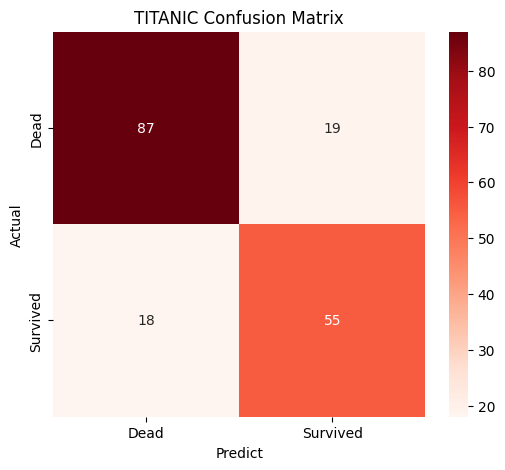

In [62]:
plt.figure(figsize=(6,5))
sb.heatmap(
    c, annot=True, fmt='d',cmap='Reds',
    xticklabels=['Dead','Survived'],
    yticklabels=['Dead','Survived']
)

plt.xlabel("Predict")
plt.ylabel("Actual")
plt.title("TITANIC Confusion Matrix")
plt.show()

In [53]:
print(classification_report(y_test, y_pred, target_names=['사망', '생존']))  # 평가 지표

              precision    recall  f1-score   support

          사망       0.83      0.82      0.82       106
          생존       0.74      0.75      0.75        73

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179

